# Directionality Example ? Generic Dataset

This notebook is dataset-agnostic. Configure the CSV path and optional column handling below.
It compares two fuzzy evaluations aligned with test4 settings:
- `fuzzy_custom`: `F(x,y)=x*(y**0.01)` with Lukasiewicz antecedent t-norm.
- `fuzzy_prod`: `F(x,y)=x*y` with product antecedent t-norm.
The crisp baseline uses classical Apriori on crisp labels.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning, module=r"IPython\.core\.pylabtools")

import itertools as it
import FIRM.base.fuzzy_data as fuzzy_data
from FIRM.methods.AARFI import AARFI_F
from mlxtend.frequent_patterns import apriori, association_rules


In [2]:
# -------------------------
# Config
# -------------------------
DATASET_PATH = "../assets/wdbc_rt.csv"  # change this
SEP = ','
DECIMAL = '.'
NA_VALUES = [-200, 'NaN', '']

USE_COLS = []  # if empty, use all columns
DROP_COLS = []  # columns to drop (e.g., ['Date','Time'])
FORCE_CATEGORICAL = []  # columns to keep as categorical strings
MAX_CATEGORIES = 20  # collapse rare categories if too many

CORR_CUTOFF = 0.9  # drop features with |corr| >= this (numeric only)
KEEP_FEATURE = "RecurrenceTime"  # never drop this feature
ONLY_KEEP_FEATURE_RULES = True  # if True, keep rules where KEEP_FEATURE is the consequent only

N_LABELS = 3
LABELS = ["L", "M", "H"]

MAX_ANT = 3
CONSEQUENT_LEN = 1  # max number of consequent items (must be >= 1)

MIN_SUPP = 0.1
MIN_COV = 0.1
MIN_CONF = 0.5
RULE_FEATURE = ""  # keep only rules involving this variable; set "" to disable

TOP_K = 10
DELTA_EPS = 0.01

pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", 0)


In [3]:
# -------------------------
# Load + preprocess
# -------------------------
df_raw = pd.read_csv(DATASET_PATH, sep=SEP, decimal=DECIMAL, na_values=NA_VALUES)
df_raw = df_raw.dropna(axis=1, how='all')

if USE_COLS:
    df_raw = df_raw[USE_COLS]
if DROP_COLS:
    df_raw = df_raw.drop(columns=DROP_COLS, errors='ignore')

def process_df(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    for col in out.columns:
        if col in FORCE_CATEGORICAL:
            out[col] = out[col].astype('object')
            continue
        # try numeric
        out[col] = pd.to_numeric(out[col], errors='ignore')
        if out[col].dtype == object:
            # cap categories if too many
            if MAX_CATEGORIES and out[col].nunique(dropna=True) > MAX_CATEGORIES:
                top = out[col].value_counts(dropna=True).index[:MAX_CATEGORIES]
                out[col] = out[col].where(out[col].isin(top), 'Other')
            out[col] = out[col].astype('object')
    return out

dataset = process_df(df_raw)
# enforce dtypes: numeric -> float, others -> object
for col in dataset.columns:
    if pd.api.types.is_numeric_dtype(dataset[col]):
        dataset[col] = dataset[col].astype(float)
    else:
        dataset[col] = dataset[col].astype('object')
# drop highly correlated numeric features
num = dataset.select_dtypes(include=[np.number])
if num.shape[1] > 1:
    corr = num.corr().abs()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    to_drop = [c for c in upper.columns if any(upper[c] >= CORR_CUTOFF)]
    if KEEP_FEATURE and KEEP_FEATURE in to_drop:
        to_drop = [c for c in to_drop if c != KEEP_FEATURE]
    if to_drop:
        dataset = dataset.drop(columns=to_drop)
dataset = dataset.dropna()
print(f"rows={len(dataset)}, cols={len(dataset.columns)}")


rows=47, cols=10


In [4]:
dataset

,Radius,Texture,Smoothness,Compactness,Concavity,Symmetry,Fractality,SizeTumor,LymphNodeStatus,RecurrenceTime
0,20.29,14.34,0.10030,0.13280,0.19800,0.1809,0.05883,0.07678,3.5,27.0
1,12.75,15.29,0.11890,0.15690,0.16640,0.1995,0.07164,0.11790,2.5,77.0
2,13.71,20.83,0.11890,0.16450,0.09366,0.2196,0.07451,0.11510,4.0,77.0
3,14.54,27.54,0.11390,0.15950,0.16390,0.2303,0.07077,0.13410,6.0,36.0
4,16.13,20.68,0.11700,0.20220,0.17220,0.2164,0.07356,0.11420,3.0,10.0
5,21.16,23.04,0.09428,0.10220,0.10970,0.1769,0.05278,0.07526,4.0,10.0
6,19.07,24.81,0.09081,0.21900,0.21070,0.2310,0.06343,0.10380,2.3,9.0
7,18.65,17.60,0.10990,0.16860,0.19740,0.1907,0.06049,0.09185,1.8,8.0
8,15.10,22.02,0.09056,0.07081,0.05253,0.1616,0.05684,0.07873,2.5,48.0
9,19.21,18.57,0.10530,0.12670,0.13230,0.1917,0.05961,0.08294,3.2,11.0


In [5]:
# -------------------------
# Fuzzify
# -------------------------
fuzzy_dataset = fuzzy_data.FuzzyDataQuantiles("symmetric", dataset, N_LABELS, LABELS)

# Crisp labels by max membership
data_crisp = dataset.copy()
for i, col in enumerate(dataset.columns):
    data_crisp[col] = dataset[col].map(lambda x: fuzzy_dataset.fv_list[i].eval_max_fuzzy_set(x))


In [6]:
# -------------------------
# Fuzzy evaluation via AARFI_F
# -------------------------
def t_luk(x, y):
    return np.maximum(x + y - 1, 0)

def t_prod(x, y):
    return x * y

F_prod = lambda x, y: x * y
F_custom = lambda x, y: x * (y ** 0.1)

def lrule_to_tokens(lrule):
    ants = []
    for (fi, li) in lrule[:-1]:
        feat = fuzzy_dataset.fv_list[fi].name
        lab = fuzzy_dataset.fv_list[fi].get_labels[li]
        ants.append(f"{feat}_{lab}")
    con_f, con_l = lrule[-1]
    con = f"{fuzzy_dataset.fv_list[con_f].name}_{fuzzy_dataset.fv_list[con_f].get_labels[con_l]}"
    return ants, con

_, fuzzy_custom = AARFI_F(
    dataset,
    fuzzy_dataset,
    T=t_luk,
    I=None,
    F=F_custom,
    min_cov=MIN_COV,
    min_supp=MIN_SUPP,
    min_conf=MIN_CONF,
    max_feat=MAX_ANT,
    prune_epsilon=DELTA_EPS,
)

_, fuzzy_prod = AARFI_F(
    dataset,
    fuzzy_dataset,
    T=t_prod,
    I=None,
    F=F_prod,
    min_cov=MIN_COV,
    min_supp=MIN_SUPP,
    min_conf=MIN_CONF,
    max_feat=MAX_ANT,
    prune_epsilon=DELTA_EPS,
)

def attach_tokens(df):
    if df.empty:
        df['ant_tokens'] = []
        df['con_token'] = []
        df['rule'] = []
        return df
    ant_tokens = []
    con_tokens = []
    for lr in df['lrule']:
        ants, con = lrule_to_tokens(lr)
        ant_tokens.append(ants)
        con_tokens.append(con)
    df = df.copy()
    df['ant_tokens'] = ant_tokens
    df['con_token'] = con_tokens
    df['rule'] = [' & '.join(a) + ' -> ' + c for a, c in zip(ant_tokens, con_tokens)]
    return df

fuzzy_custom = attach_tokens(fuzzy_custom)
fuzzy_prod = attach_tokens(fuzzy_prod)


In [7]:
# -------------------------
# Crisp evaluation (Apriori)
# -------------------------
def eval_crisp_apriori(data_crisp):
    max_consequent_len = int(np.floor(CONSEQUENT_LEN))
    if max_consequent_len < 1:
        raise ValueError(f"CONSEQUENT_LEN must be >= 1 for itemset length filtering, got {CONSEQUENT_LEN}")

    df_encoded = pd.get_dummies(data_crisp, columns=data_crisp.columns)
    df_freq = apriori(
        df_encoded,
        min_support=MIN_SUPP,
        use_colnames=True,
        verbose=1,
        max_len=MAX_ANT + max_consequent_len,
        low_memory=True,
    )
    if df_freq.empty:
        return pd.DataFrame(columns=['rule','ant_tokens','con_token','n_antecedents','support','coverage','confidence'])
    df_ar = association_rules(df_freq, metric="confidence", min_threshold=MIN_CONF)
    if df_ar.empty:
        return pd.DataFrame(columns=['rule','ant_tokens','con_token','n_antecedents','support','coverage','confidence'])
    df_rules_filtered = df_ar[
        (df_ar['antecedents'].apply(len) <= MAX_ANT) &
        (df_ar['consequents'].apply(len) <= max_consequent_len)
    ].reset_index(drop=True)
    if df_rules_filtered.empty:
        return pd.DataFrame(columns=['rule','ant_tokens','con_token','n_antecedents','support','coverage','confidence'])
    if 'antecedent support' in df_rules_filtered.columns:
        coverage_col = 'antecedent support'
    elif 'antecedent_support' in df_rules_filtered.columns:
        coverage_col = 'antecedent_support'
    else:
        raise KeyError(f"Could not find antecedent-support column in association_rules output: {list(df_rules_filtered.columns)}")
    rows = []
    for _, r in df_rules_filtered.iterrows():
        ant_tokens = sorted([str(t) for t in r['antecedents']])
        con_tokens = sorted([str(t) for t in r['consequents']])
        if not con_tokens:
            continue
        con_token = con_tokens[0]
        rows.append({
            'rule': ' & '.join(ant_tokens) + ' -> ' + con_token,
            'ant_tokens': ant_tokens,
            'con_token': con_token,
            'n_antecedents': len(ant_tokens),
            'support': float(r['support']),
            'coverage': float(r[coverage_col]),
            'confidence': float(r['confidence']),
        })
    return pd.DataFrame(rows)

crisp_apriori = eval_crisp_apriori(data_crisp)


Processing 365 combinations | Sampling itemset size 4


In [8]:
# -------------------------
# Apply thresholds and top rules
# -------------------------
def token_feature(token):
    t = str(token)
    return t.rsplit('_', 1)[0] if '_' in t else t

def rule_has_feature(row, feature_name):
    if not feature_name:
        return True
    f = feature_name.strip().lower()
    ants = row['ant_tokens'] if isinstance(row['ant_tokens'], list) else []
    cons = [row['con_token']] if isinstance(row['con_token'], str) else []
    vars_in_rule = {token_feature(tok).strip().lower() for tok in (ants + cons)}
    return f in vars_in_rule

def rule_has_feature_consequent_only(row, feature_name):
    if not feature_name:
        return True
    f = feature_name.strip().lower()
    ants = row['ant_tokens'] if isinstance(row['ant_tokens'], list) else []
    con = row['con_token'] if isinstance(row['con_token'], str) else ''
    ant_has = any(token_feature(tok).strip().lower() == f for tok in ants)
    con_has = token_feature(con).strip().lower() == f if con else False
    return con_has and not ant_has

def apply_thresholds(df):
    out = df[(df['support'] >= MIN_SUPP) & (df['coverage'] >= MIN_COV) & (df['confidence'] >= MIN_CONF)].copy()
    if RULE_FEATURE:
        out = out[out.apply(lambda r: rule_has_feature(r, RULE_FEATURE), axis=1)].copy()
    if ONLY_KEEP_FEATURE_RULES and KEEP_FEATURE:
        out = out[out.apply(lambda r: rule_has_feature_consequent_only(r, KEEP_FEATURE), axis=1)].copy()
    return out


def prune_redundant_df(df, epsilon):
    if df.empty:
        return df
    groups = []
    for con, group in df.groupby('con_token', sort=False):
        group_sorted = group.sort_values('n_antecedents', kind='mergesort')
        kept_idx = []
        kept_ants = []
        kept_conf = []
        for idx, row in group_sorted.iterrows():
            A1 = set(row['ant_tokens'])
            c1 = float(row['confidence'])
            redundant = False
            for A2, c2 in zip(kept_ants, kept_conf):
                if A2.issubset(A1) and abs(c1 - c2) < epsilon:
                    redundant = True
                    break
            if not redundant:
                kept_idx.append(idx)
                kept_ants.append(A1)
                kept_conf.append(c1)
        groups.append(group_sorted.loc[kept_idx])
    return pd.concat(groups, ignore_index=True) if groups else df.iloc[0:0]
def top_k(df):
    return df.sort_values(['confidence', 'support'], ascending=False).head(TOP_K).reset_index(drop=True)

fuzzy_custom_keep = apply_thresholds(fuzzy_custom)
fuzzy_prod_keep = apply_thresholds(fuzzy_prod)
crisp_keep = apply_thresholds(crisp_apriori)

crisp_keep = prune_redundant_df(crisp_keep, DELTA_EPS)

if RULE_FEATURE:
    print('rule variable filter:', RULE_FEATURE)

print('retained rules:')
print('fuzzy_custom:', len(fuzzy_custom_keep))
print('fuzzy_prod:', len(fuzzy_prod_keep))
print('crisp_apriori:', len(crisp_keep))

print('top rules (fuzzy_custom)')
display(top_k(fuzzy_custom_keep)[['rule','confidence','support','coverage','n_antecedents']])
print('top rules (fuzzy_prod)')
display(top_k(fuzzy_prod_keep)[['rule','confidence','support','coverage','n_antecedents']])
print('top rules (crisp_apriori)')
display(top_k(crisp_keep)[['rule','confidence','support','coverage','n_antecedents']])


retained rules:
fuzzy_custom: 86
fuzzy_prod: 49
crisp_apriori: 74
top rules (fuzzy_custom)


,rule,confidence,support,coverage,n_antecedents
0,Radius_H & Concavity_H & SizeTumor_M -> RecurrenceTime_L,0.922622,0.104919,0.113719,3
1,Fractality_M & SizeTumor_M -> RecurrenceTime_L,0.909157,0.110611,0.121664,2
2,Compactness_H & Concavity_H & Fractality_M -> RecurrenceTime_L,0.908827,0.122782,0.135099,3
3,Radius_L & SizeTumor_H & LymphNodeStatus_L -> RecurrenceTime_H,0.898559,0.111230,0.123787,3
4,Concavity_H & SizeTumor_M -> RecurrenceTime_L,0.888303,0.138541,0.155962,2
5,Concavity_H & Fractality_M -> RecurrenceTime_L,0.884210,0.148143,0.167542,2
6,Radius_H & SizeTumor_M -> RecurrenceTime_L,0.882311,0.107899,0.122291,2
7,Radius_L & Fractality_H & LymphNodeStatus_L -> RecurrenceTime_H,0.864535,0.101996,0.117977,3
8,Fractality_H & SizeTumor_H & LymphNodeStatus_L -> RecurrenceTime_H,0.862174,0.119023,0.138049,3
9,Radius_L & Symmetry_H & Fractality_H -> RecurrenceTime_H,0.853121,0.119871,0.140509,3


top rules (fuzzy_prod)


,rule,confidence,support,coverage,n_antecedents
0,Radius_H & Concavity_H & SizeTumor_M -> RecurrenceTime_L,0.843583,0.104039,0.123330,3
1,Compactness_H & Concavity_H & Fractality_M -> RecurrenceTime_L,0.820227,0.118528,0.144506,3
2,Compactness_H & Concavity_H & SizeTumor_M -> RecurrenceTime_L,0.818115,0.117479,0.143598,3
3,Radius_L & Symmetry_H & Fractality_H -> RecurrenceTime_H,0.813874,0.120141,0.147617,3
4,Radius_L & Smoothness_H & Symmetry_H -> RecurrenceTime_H,0.802949,0.108383,0.134982,3
5,Radius_L & Symmetry_H & SizeTumor_H -> RecurrenceTime_H,0.802614,0.112753,0.140483,3
6,Radius_H & SizeTumor_M -> RecurrenceTime_L,0.800376,0.108328,0.135346,2
7,Compactness_H & SizeTumor_M -> RecurrenceTime_L,0.792007,0.122055,0.154109,2
8,Concavity_H & SizeTumor_M -> RecurrenceTime_L,0.763403,0.125517,0.164418,2
9,Smoothness_H & Compactness_H & Fractality_H -> RecurrenceTime_H,0.751972,0.114764,0.152618,3


top rules (crisp_apriori)


,rule,confidence,support,coverage,n_antecedents
0,Compactness_H & Concavity_H & Fractality_M -> RecurrenceTime_L,1.000000,0.127660,0.127660,3
1,Compactness_H & Fractality_M & SizeTumor_M -> RecurrenceTime_L,1.000000,0.127660,0.127660,3
2,Radius_H & SizeTumor_M -> RecurrenceTime_L,1.000000,0.106383,0.106383,2
3,LymphNodeStatus_L & Radius_L & Symmetry_H -> RecurrenceTime_H,1.000000,0.106383,0.106383,3
4,Compactness_H & SizeTumor_M -> RecurrenceTime_L,0.875000,0.148936,0.170213,2
5,Compactness_H & Radius_H -> RecurrenceTime_L,0.857143,0.127660,0.148936,2
6,Concavity_H & Fractality_M & SizeTumor_M -> RecurrenceTime_L,0.857143,0.127660,0.148936,3
7,Fractality_H & Radius_L & Symmetry_H -> RecurrenceTime_H,0.857143,0.127660,0.148936,3
8,Radius_L & SizeTumor_H & Symmetry_H -> RecurrenceTime_H,0.857143,0.127660,0.148936,3
9,Compactness_H & Fractality_H & Smoothness_H -> RecurrenceTime_H,0.857143,0.127660,0.148936,3


fuzzy_custom (retained) symmetry rate: 0.0 (0/25)
fuzzy_prod (retained) symmetry rate: 0.0 (0/9)
crisp_apriori (retained) symmetry rate: 0.0 (0/15)
Symmetry summary (retained 1->1 rules)


,method,n_directed_rules,n_unique_pairs,n_symmetric_pairs,symmetry_rate,bidirectional_rule_fraction
0,fuzzy_custom (retained),25,25,0,0.0,0.0
1,fuzzy_prod (retained),9,9,0,0.0,0.0
2,crisp_apriori (retained),15,15,0,0.0,0.0


C:\Users\Raquel\PycharmProjects\FIRM\.venv\Lib\site-packages\IPython\core\pylabtools.py:77: DeprecationWarning: backend2gui is deprecated since IPython 8.24, backends are managed in matplotlib and can be externally registered.
  warnings.warn(
C:\Users\Raquel\PycharmProjects\FIRM\.venv\Lib\site-packages\IPython\core\pylabtools.py:77: DeprecationWarning: backend2gui is deprecated since IPython 8.24, backends are managed in matplotlib and can be externally registered.
  warnings.warn(
C:\Users\Raquel\PycharmProjects\FIRM\.venv\Lib\site-packages\IPython\core\pylabtools.py:77: DeprecationWarning: backend2gui is deprecated since IPython 8.24, backends are managed in matplotlib and can be externally registered.
  warnings.warn(
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


fuzzy_custom (retained) confidence no bidirectional 1->1 pairs
fuzzy_prod (retained) confidence no bidirectional 1->1 pairs
crisp_apriori (retained) confidence no bidirectional 1->1 pairs


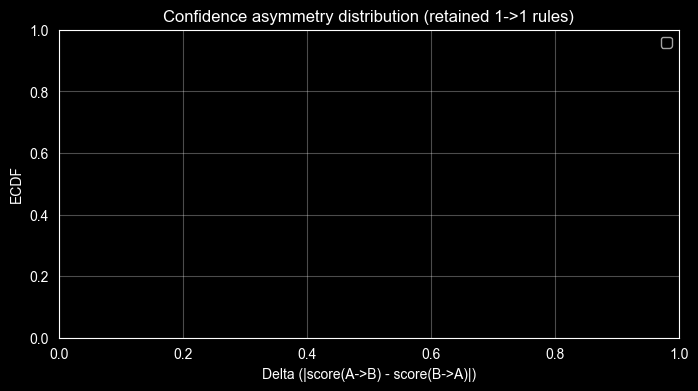

In [9]:
# -------------------------
# Directionality analysis (retained 1->1 rules)
# -------------------------
def pair_score_map(df, score_col):
    one_one = df[df['n_antecedents'] == 1]
    out = {}
    for _, r in one_one.iterrows():
        if not r['ant_tokens']:
            continue
        a = r['ant_tokens'][0]
        b = r['con_token']
        if a == b:
            continue
        out[(a, b)] = float(r[score_col])
    return out

def asymmetry_stats(df, name, score_col='confidence'):
    score = pair_score_map(df, score_col)
    deltas = []
    seen = set()
    for (a, b), v in score.items():
        pair_key = tuple(sorted((a, b)))
        if pair_key in seen:
            continue
        seen.add(pair_key)
        if (b, a) in score:
            deltas.append(abs(v - score[(b, a)]))
    deltas = np.array(deltas, dtype=float)
    if len(deltas) == 0:
        print(name, score_col, 'no bidirectional 1->1 pairs')
        return deltas
    print(name, score_col, 'avg Delta:', float(deltas.mean()))
    print(name, score_col, 'prop Delta <', DELTA_EPS, ':', float((deltas < DELTA_EPS).mean()))
    return deltas

def symmetry_stats_retained(df, name):
    directed = set(pair_score_map(df, 'confidence').keys())
    pair_keys = {tuple(sorted((a, b))) for (a, b) in directed}
    if len(pair_keys) == 0:
        print(name, 'no retained 1->1 pairs')
        return {
            'method': name,
            'n_directed_rules': 0,
            'n_unique_pairs': 0,
            'n_symmetric_pairs': 0,
            'symmetry_rate': np.nan,
            'bidirectional_rule_fraction': np.nan,
        }
    n_symmetric_pairs = 0
    for a, b in pair_keys:
        if (a, b) in directed and (b, a) in directed:
            n_symmetric_pairs += 1
    symmetry_rate = n_symmetric_pairs / len(pair_keys)
    bidirectional_rule_fraction = (2.0 * n_symmetric_pairs) / len(directed)
    print(name, 'symmetry rate:', float(symmetry_rate), f"({n_symmetric_pairs}/{len(pair_keys)})")
    return {
        'method': name,
        'n_directed_rules': len(directed),
        'n_unique_pairs': len(pair_keys),
        'n_symmetric_pairs': n_symmetric_pairs,
        'symmetry_rate': float(symmetry_rate),
        'bidirectional_rule_fraction': float(bidirectional_rule_fraction),
    }

sym_custom = symmetry_stats_retained(fuzzy_custom_keep, 'fuzzy_custom (retained)')
sym_prod = symmetry_stats_retained(fuzzy_prod_keep, 'fuzzy_prod (retained)')
sym_crisp = symmetry_stats_retained(crisp_keep, 'crisp_apriori (retained)')

symmetry_df = pd.DataFrame([sym_custom, sym_prod, sym_crisp])
print('Symmetry summary (retained 1->1 rules)')
display(symmetry_df)

d_custom_conf = asymmetry_stats(fuzzy_custom_keep, 'fuzzy_custom (retained)', score_col='confidence')
d_prod_conf = asymmetry_stats(fuzzy_prod_keep, 'fuzzy_prod (retained)', score_col='confidence')
d_crisp_conf = asymmetry_stats(crisp_keep, 'crisp_apriori (retained)', score_col='confidence')

def ecdf(x):
    x = np.sort(x)
    y = np.arange(1, len(x) + 1) / len(x)
    return x, y

plt.figure(figsize=(8,4))
for data, label in [(d_custom_conf, 'fuzzy_custom'), (d_prod_conf, 'fuzzy_prod'), (d_crisp_conf, 'crisp_apriori')]:
    if len(data) == 0:
        continue
    x, y = ecdf(data)
    plt.plot(x, y, label=label)

plt.xlabel('Delta (|score(A->B) - score(B->A)|)')
plt.ylabel('ECDF')
plt.legend()
plt.title('Confidence asymmetry distribution (retained 1->1 rules)')
plt.grid(True, alpha=0.3)
plt.show()
